In [2]:
pip install pandas numpy matplotlib seaborn scikit-learn pyarrow

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer


In [4]:
# Set random seed for reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [5]:
# ==========================================
# 1. DATA LOADING & AUDIT
# ==========================================
# Download a single monthly Parquet file directly from NYC TLC official S3 bucket
# Example: Yellow Taxi Trip Records for January 2023 (~3 million rows raw)
parquet_url = "https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2023-01.parquet"

print("Downloading and loading NYC TLC Parquet data...")
# Sampling 100,000 rows to ensure fast execution during training
raw_df = pd.read_parquet(parquet_url).sample(n=100000, random_state=RANDOM_STATE)

print("--- Raw Dataset Audit ---")
print(f"Sampled Dataset Shape: {raw_df.shape}")
print("\nData Types:")
print(raw_df.dtypes)
print("\nMissing Values Count:")
print(raw_df.isnull().sum())

--- Raw Dataset Audit ---
Sampled Dataset Shape: (100000, 19)

Data Types:
VendorID                          int64
tpep_pickup_datetime     datetime64[us]
tpep_dropoff_datetime    datetime64[us]
passenger_count                 float64
trip_distance                   float64
RatecodeID                      float64
store_and_fwd_flag                  str
PULocationID                      int64
DOLocationID                      int64
payment_type                      int64
fare_amount                     float64
extra                           float64
mta_tax                         float64
tip_amount                      float64
tolls_amount                    float64
improvement_surcharge           float64
total_amount                    float64
congestion_surcharge            float64
airport_fee                     float64
dtype: object

Missing Values Count:
VendorID                    0
tpep_pickup_datetime        0
tpep_dropoff_datetime       0
passenger_count          2286
trip_dis

In [6]:
# ==========================================
# 2. DATA CLEANING
# ==========================================
df = raw_df.copy()

# Datetime Parsing & Duration
df['tpep_pickup_datetime'] = pd.to_datetime(df['tpep_pickup_datetime'])
df['tpep_dropoff_datetime'] = pd.to_datetime(df['tpep_dropoff_datetime'])
df['trip_duration_min'] = (df['tpep_dropoff_datetime'] - df['tpep_pickup_datetime']).dt.total_seconds() / 60.0

# Outlier Filtering
df = df[
    (df['trip_distance'] > 0.1) & (df['trip_distance'] < 100) &
    (df['fare_amount'] > 2.5) & (df['fare_amount'] < 300) &
    (df['trip_duration_min'] > 1.0) & (df['trip_duration_min'] < 180) &
    (df['passenger_count'] > 0) & (df['passenger_count'] <= 6)
].copy()

# Fill Categorical NAs
df['RatecodeID'] = df['RatecodeID'].fillna(1.0).astype(str)
df['store_and_fwd_flag'] = df['store_and_fwd_flag'].fillna('N')
df['payment_type'] = df['payment_type'].astype(str)

In [7]:
# ==========================================
# 3. FEATURE ENGINEERING
# ==========================================
df['pickup_hour'] = df['tpep_pickup_datetime'].dt.hour
df['day_of_week'] = df['tpep_pickup_datetime'].dt.day_name()
df['is_weekend'] = df['tpep_pickup_datetime'].dt.dayofweek.isin([5, 6]).astype(int)

df['PULocationID'] = df['PULocationID'].astype(str)
df['DOLocationID'] = df['DOLocationID'].astype(str)

X = df[['PULocationID', 'DOLocationID', 'day_of_week', 'payment_type', 
        'passenger_count', 'trip_distance', 'trip_duration_min', 'pickup_hour', 'is_weekend']]
y = df['fare_amount']

num_features = ['passenger_count', 'trip_distance', 'trip_duration_min', 'pickup_hour', 'is_weekend']
cat_features = ['PULocationID', 'DOLocationID', 'day_of_week', 'payment_type']

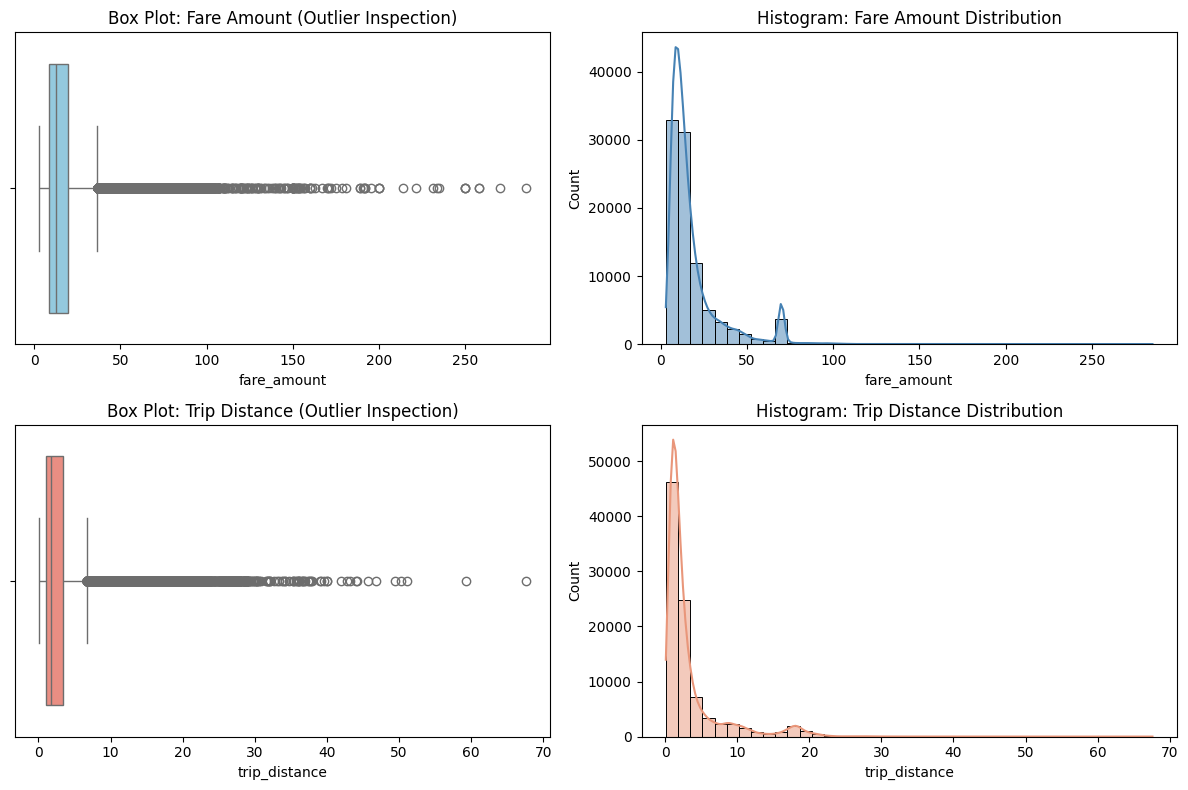

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Boxplot & Histogram for Target (Fare Amount)
sns.boxplot(x=df['fare_amount'], ax=axes[0, 0], color='skyblue')
axes[0, 0].set_title('Box Plot: Fare Amount (Outlier Inspection)')

sns.histplot(df['fare_amount'], bins=40, kde=True, ax=axes[0, 1], color='steelblue')
axes[0, 1].set_title('Histogram: Fare Amount Distribution')

# Boxplot & Histogram for Feature (Trip Distance)
sns.boxplot(x=df['trip_distance'], ax=axes[1, 0], color='salmon')
axes[1, 0].set_title('Box Plot: Trip Distance (Outlier Inspection)')

sns.histplot(df['trip_distance'], bins=40, kde=True, ax=axes[1, 1], color='darksalmon')
axes[1, 1].set_title('Histogram: Trip Distance Distribution')

plt.tight_layout()
plt.show()

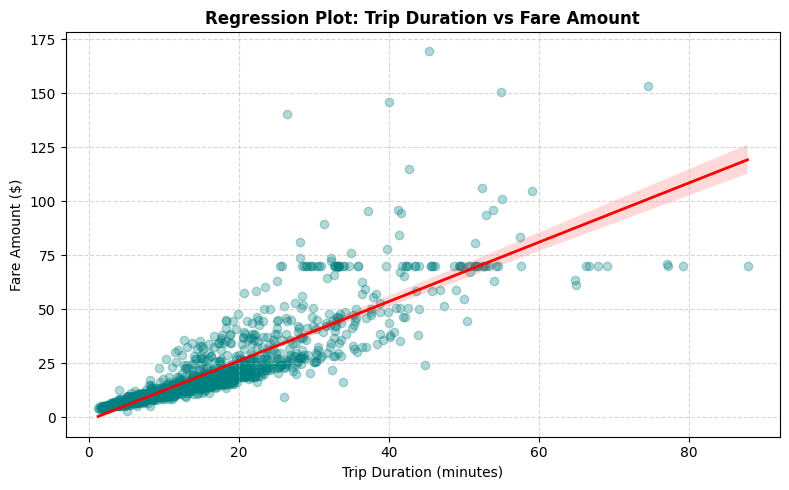

In [9]:
plt.figure(figsize=(8, 5))
# Sampling 2,000 points for clear scatter visualization with regression line
sns.regplot(
    data=df.sample(2000, random_state=RANDOM_STATE), 
    x='trip_duration_min', 
    y='fare_amount', 
    scatter_kws={'alpha':0.3, 'color':'teal'}, 
    line_kws={'color':'red', 'linewidth':2}
)
plt.title('Regression Plot: Trip Duration vs Fare Amount', fontsize=12, fontweight='bold')
plt.xlabel('Trip Duration (minutes)')
plt.ylabel('Fare Amount ($)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

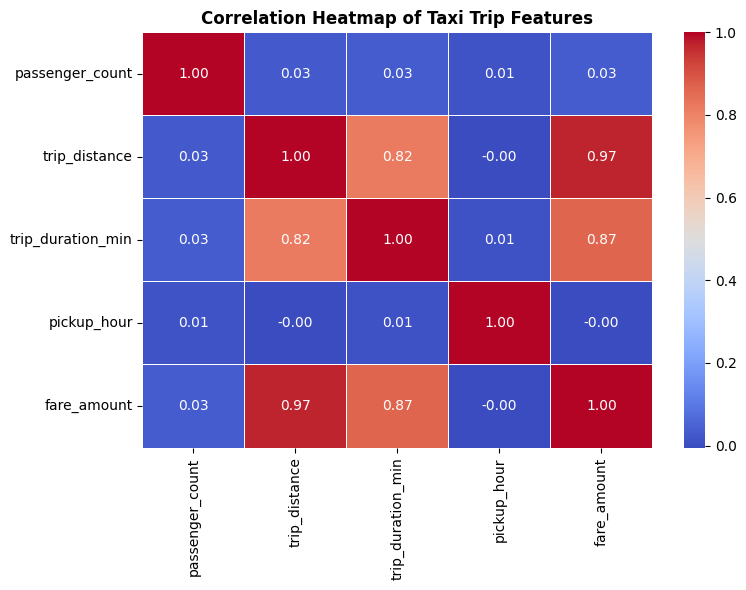

In [10]:
plt.figure(figsize=(8, 6))

num_cols = ['passenger_count', 'trip_distance', 'trip_duration_min', 'pickup_hour', 'fare_amount']
corr = df[num_cols].corr()

sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap of Taxi Trip Features', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

In [12]:
# ==========================================
# 4. PREPROCESSING & TRAIN-TEST SPLIT
# ==========================================
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=RANDOM_STATE)

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_features),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False), cat_features)
    ]
)

# Fit ONLY on Training Data
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("\n--- Pipeline Status ---")
print(f"Cleaned Dataset Shape: {df.shape}")
print(f"X_train Shape: {X_train_processed.shape}")
print(f"X_test Shape: {X_test_processed.shape}")


--- Pipeline Status ---
Cleaned Dataset Shape: (93604, 23)
X_train Shape: (74883, 453)
X_test Shape: (18721, 453)


C:\Python313\Lib\site-packages\sklearn\preprocessing\_encoders.py:262: UserWarning: Found unknown categories in columns [0, 1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


In [13]:
# Linear Regression

from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, root_mean_squared_error, mean_absolute_error

# Train Model 1
lr = LinearRegression()
lr.fit(X_train_processed, y_train)

# Predict
y_pred_lr = lr.predict(X_test_processed)

# Evaluate
lr_r2 = r2_score(y_test, y_pred_lr)
lr_rmse = root_mean_squared_error(y_test, y_pred_lr)
lr_mae = mean_absolute_error(y_test, y_pred_lr)

print(f"Model 1: Linear Regression")
print(f"R2 Score: {lr_r2:.4f} | RMSE: {lr_rmse:.4f} | MAE: {lr_mae:.4f}")

Model 1: Linear Regression
R2 Score: 0.9705 | RMSE: 2.8488 | MAE: 1.1485


In [14]:
# Ridge Regression

from sklearn.linear_model import Ridge

# Train Model 2
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_processed, y_train)

# Predict
y_pred_ridge = ridge.predict(X_test_processed)

# Evaluate
ridge_r2 = r2_score(y_test, y_pred_ridge)
ridge_rmse = root_mean_squared_error(y_test, y_pred_ridge)
ridge_mae = mean_absolute_error(y_test, y_pred_ridge)

print(f"Model 2: Ridge Regression")
print(f"R2 Score: {ridge_r2:.4f} | RMSE: {ridge_rmse:.4f} | MAE: {ridge_mae:.4f}")

Model 2: Ridge Regression
R2 Score: 0.9704 | RMSE: 2.8554 | MAE: 1.1767


In [15]:
# Lasso Regression

from sklearn.linear_model import Lasso

# Train Model 3
lasso = Lasso(alpha=0.1)
lasso.fit(X_train_processed, y_train)

# Predict
y_pred_lasso = lasso.predict(X_test_processed)

# Evaluate
lasso_r2 = r2_score(y_test, y_pred_lasso)
lasso_rmse = root_mean_squared_error(y_test, y_pred_lasso)
lasso_mae = mean_absolute_error(y_test, y_pred_lasso)

print(f"Model 3: Lasso Regression")
print(f"R2 Score: {lasso_r2:.4f} | RMSE: {lasso_rmse:.4f} | MAE: {lasso_mae:.4f}")

Model 3: Lasso Regression
R2 Score: 0.9606 | RMSE: 3.2940 | MAE: 1.2425


In [16]:
# ElasticNet Regression

from sklearn.linear_model import ElasticNet

# Train Model 4
enet = ElasticNet(alpha=0.1, l1_ratio=0.5, random_state=RANDOM_STATE)
enet.fit(X_train_processed, y_train)

# Predict
y_pred_enet = enet.predict(X_test_processed)

# Evaluate
enet_r2 = r2_score(y_test, y_pred_enet)
enet_rmse = root_mean_squared_error(y_test, y_pred_enet)
enet_mae = mean_absolute_error(y_test, y_pred_enet)

print(f"Model 4: ElasticNet Regression")
print(f"R2 Score: {enet_r2:.4f} | RMSE: {enet_rmse:.4f} | MAE: {enet_mae:.4f}")

Model 4: ElasticNet Regression
R2 Score: 0.9591 | RMSE: 3.3550 | MAE: 1.2090


In [17]:
# Polynomial Regression (Degree 2 on Numerical Features)

from sklearn.preprocessing import PolynomialFeatures

# Apply PolynomialFeatures only on numerical features to avoid memory overhead
poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_num_poly = poly.fit_transform(X_train[num_features])
X_test_num_poly = poly.transform(X_test[num_features])

# Fit scaler and encoder for polynomial numerical features + original categoricals
from sklearn.pipeline import FeatureUnion

# Scale polynomial features and concatenate with encoded categoricals
scaler_poly = StandardScaler()
X_train_num_poly_scaled = scaler_poly.fit_transform(X_train_num_poly)
X_test_num_poly_scaled = scaler_poly.transform(X_test_num_poly)

# One-hot encode categoricals separately for poly pipeline
ohe_poly = OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False)
X_train_cat_ohe = ohe_poly.fit_transform(X_train[cat_features])
X_test_cat_ohe = ohe_poly.transform(X_test[cat_features])

X_train_poly_full = np.hstack([X_train_num_poly_scaled, X_train_cat_ohe])
X_test_poly_full = np.hstack([X_test_num_poly_scaled, X_test_cat_ohe])

# Train Model 5
poly_lr = LinearRegression()
poly_lr.fit(X_train_poly_full, y_train)

# Predict
y_pred_poly = poly_lr.predict(X_test_poly_full)

# Evaluate
poly_r2 = r2_score(y_test, y_pred_poly)
poly_rmse = root_mean_squared_error(y_test, y_pred_poly)
poly_mae = mean_absolute_error(y_test, y_pred_poly)

print(f"Model 5: Polynomial Regression (Degree 2)")
print(f"R2 Score: {poly_r2:.4f} | RMSE: {poly_rmse:.4f} | MAE: {poly_mae:.4f}")

C:\Python313\Lib\site-packages\sklearn\preprocessing\_encoders.py:262: UserWarning: Found unknown categories in columns [0, 1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


Model 5: Polynomial Regression (Degree 2)
R2 Score: 0.9732 | RMSE: 2.7165 | MAE: 0.9372


In [18]:
member1_results = pd.DataFrame({
    'Algorithm': ['Linear Regression', 'Ridge Regression', 'Lasso Regression', 'ElasticNet Regression', 'Polynomial Regression'],
    'R2 Score': [lr_r2, ridge_r2, lasso_r2, enet_r2, poly_r2],
    'RMSE': [lr_rmse, ridge_rmse, lasso_rmse, enet_rmse, poly_rmse],
    'MAE': [lr_mae, ridge_mae, lasso_mae, enet_mae, poly_mae]
})

member1_results.sort_values(by='R2 Score', ascending=False, inplace=True)
print("--- Member 1 Regression Results ---")
print(member1_results.to_string(index=False))

--- Member 1 Regression Results ---
            Algorithm  R2 Score     RMSE      MAE
Polynomial Regression  0.973172 2.716473 0.937246
    Linear Regression  0.970494 2.848825 1.148516
     Ridge Regression  0.970357 2.855444 1.176707
     Lasso Regression  0.960552 3.294006 1.242500
ElasticNet Regression  0.959077 3.355050 1.209020


In [19]:
# Decision Tree Regressor

from sklearn.tree import DecisionTreeRegressor

# Train Model 6
dt_reg = DecisionTreeRegressor(max_depth=10, random_state=RANDOM_STATE)
dt_reg.fit(X_train_processed, y_train)

# Predict
y_pred_dt = dt_reg.predict(X_test_processed)

# Evaluate
dt_r2 = r2_score(y_test, y_pred_dt)
dt_rmse = root_mean_squared_error(y_test, y_pred_dt)
dt_mae = mean_absolute_error(y_test, y_pred_dt)

print(f"Model 6: Decision Tree Regressor")
print(f"R2 Score: {dt_r2:.4f} | RMSE: {dt_rmse:.4f} | MAE: {dt_mae:.4f}")

Model 6: Decision Tree Regressor
R2 Score: 0.9636 | RMSE: 3.1654 | MAE: 0.9215


In [20]:
# Random Forest Regressor 

from sklearn.ensemble import RandomForestRegressor

# Train Model 7 (using n_jobs=-1 for faster execution)
rf_reg = RandomForestRegressor(n_estimators=100, max_depth=12, random_state=RANDOM_STATE, n_jobs=-1)
rf_reg.fit(X_train_processed, y_train)

# Predict
y_pred_rf = rf_reg.predict(X_test_processed)

# Evaluate
rf_r2 = r2_score(y_test, y_pred_rf)
rf_rmse = root_mean_squared_error(y_test, y_pred_rf)
rf_mae = mean_absolute_error(y_test, y_pred_rf)

print(f"Model 7: Random Forest Regressor")
print(f"R2 Score: {rf_r2:.4f} | RMSE: {rf_rmse:.4f} | MAE: {rf_mae:.4f}")

Model 7: Random Forest Regressor
R2 Score: 0.9772 | RMSE: 2.5049 | MAE: 0.7466


In [21]:
# Gradient Boosting Regressor

from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import r2_score, root_mean_squared_error, mean_absolute_error

# Train Model 8 using HistGradientBoosting (Ultra-fast & handles large feature matrices natively)
gb_reg = HistGradientBoostingRegressor(max_iter=100, random_state=RANDOM_STATE)
gb_reg.fit(X_train_processed, y_train)

# Predict
y_pred_gb = gb_reg.predict(X_test_processed)

# Evaluate
gb_r2 = r2_score(y_test, y_pred_gb)
gb_rmse = root_mean_squared_error(y_test, y_pred_gb)
gb_mae = mean_absolute_error(y_test, y_pred_gb)

print(f"Model 8: HistGradient Boosting Regressor")
print(f"R2 Score: {gb_r2:.4f} | RMSE: {gb_rmse:.4f} | MAE: {gb_mae:.4f}")

Model 8: HistGradient Boosting Regressor
R2 Score: 0.9731 | RMSE: 2.7189 | MAE: 0.8014


In [22]:
#SVR

from sklearn.svm import LinearSVR
from sklearn.metrics import r2_score, root_mean_squared_error, mean_absolute_error

# Train Model 9 using LinearSVR on the full dataset
svr_reg = LinearSVR(C=1.0, max_iter=3000, random_state=RANDOM_STATE)
svr_reg.fit(X_train_processed, y_train)

# Predict & Evaluate
y_pred_svr = svr_reg.predict(X_test_processed)

svr_r2 = r2_score(y_test, y_pred_svr)
svr_rmse = root_mean_squared_error(y_test, y_pred_svr)
svr_mae = mean_absolute_error(y_test, y_pred_svr)

print(f"Model 9: Support Vector Regressor (LinearSVR)")
print(f"R2 Score: {svr_r2:.4f} | RMSE: {svr_rmse:.4f} | MAE: {svr_mae:.4f}")

Model 9: Support Vector Regressor (LinearSVR)
R2 Score: 0.9650 | RMSE: 3.1041 | MAE: 1.0289


In [23]:
# KNN Regressor

from sklearn.neighbors import KNeighborsRegressor

# Train Model 10
knn_reg = KNeighborsRegressor(n_neighbors=5, weights='distance', n_jobs=-1)
knn_reg.fit(X_train_processed, y_train)

# Predict
y_pred_knn = knn_reg.predict(X_test_processed)

# Evaluate
knn_r2 = r2_score(y_test, y_pred_knn)
knn_rmse = root_mean_squared_error(y_test, y_pred_knn)
knn_mae = mean_absolute_error(y_test, y_pred_knn)

print(f"Model 10: K-Nearest Neighbors Regressor")
print(f"R2 Score: {knn_r2:.4f} | RMSE: {knn_rmse:.4f} | MAE: {knn_mae:.4f}")

Model 10: K-Nearest Neighbors Regressor
R2 Score: 0.9520 | RMSE: 3.6330 | MAE: 1.9033


In [24]:
member2_results = pd.DataFrame({
    'Algorithm': [
        'Decision Tree Regressor', 
        'Random Forest Regressor', 
        'Gradient Boosting Regressor', 
        'Support Vector Regressor', 
        'K-Nearest Neighbors Regressor'
    ],
    'R2 Score': [dt_r2, rf_r2, gb_r2, svr_r2, knn_r2],
    'RMSE': [dt_rmse, rf_rmse, gb_rmse, svr_rmse, knn_rmse],
    'MAE': [dt_mae, rf_mae, gb_mae, svr_mae, knn_mae]
})

# Rank models by R2 Score
member2_results.sort_values(by='R2 Score', ascending=False, inplace=True)
member2_results.reset_index(drop=True, inplace=True)

print("--- Member 2 Regression Results (Models 6–10) ---")
print(member2_results.to_string(index=False))

--- Member 2 Regression Results (Models 6–10) ---
                    Algorithm  R2 Score     RMSE      MAE
      Random Forest Regressor  0.977188 2.504933 0.746594
  Gradient Boosting Regressor  0.973124 2.718903 0.801373
     Support Vector Regressor  0.964971 3.104054 1.028885
      Decision Tree Regressor  0.963573 3.165363 0.921508
K-Nearest Neighbors Regressor  0.952015 3.633005 1.903298


In [25]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [26]:

# ==========================================
# Create discrete classes directly from y_train and y_test to keep dimensions aligned
y_train_cls = pd.qcut(y_train, q=3, labels=['Low', 'Medium', 'High'])
y_test_cls = pd.qcut(y_test, q=3, labels=['Low', 'Medium', 'High'])

# Assign preprocessed feature matrices directly
X_train_cls = X_train_processed
X_test_cls = X_test_processed

In [27]:
# Logistic Regression

from sklearn.linear_model import SGDClassifier

# Stochastic Gradient Descent Logistic Regression (Runs instantly on large matrices)
log_reg = SGDClassifier(loss='log_loss', max_iter=200, random_state=RANDOM_STATE)
log_reg.fit(X_train_cls, y_train_cls)

y_pred_lr = log_reg.predict(X_test_cls)

lr_acc = accuracy_score(y_test_cls, y_pred_lr)
lr_f1 = f1_score(y_test_cls, y_pred_lr, average='weighted')
lr_prec = precision_score(y_test_cls, y_pred_lr, average='weighted')
lr_rec = recall_score(y_test_cls, y_pred_lr, average='weighted')

print(f"Model 1: Logistic Regression")
print(f"Accuracy: {lr_acc:.4f} | F1-Score: {lr_f1:.4f} | Precision: {lr_prec:.4f} | Recall: {lr_rec:.4f}")

Model 1: Logistic Regression
Accuracy: 0.9347 | F1-Score: 0.9344 | Precision: 0.9354 | Recall: 0.9347


In [28]:
# KNN Classifier

from sklearn.neighbors import KNeighborsClassifier

# Subsample 20,000 training rows for fast distance indexing
knn_cls = KNeighborsClassifier(n_neighbors=5, weights='distance', n_jobs=-1)
knn_cls.fit(X_train_cls[:20000], y_train_cls[:20000])

y_pred_knn = knn_cls.predict(X_test_cls)

knn_acc = accuracy_score(y_test_cls, y_pred_knn)
knn_f1 = f1_score(y_test_cls, y_pred_knn, average='weighted')
knn_prec = precision_score(y_test_cls, y_pred_knn, average='weighted')
knn_rec = recall_score(y_test_cls, y_pred_knn, average='weighted')

print(f"Model 2: K-Nearest Neighbors Classifier")
print(f"Accuracy: {knn_acc:.4f} | F1-Score: {knn_f1:.4f} | Precision: {knn_prec:.4f} | Recall: {knn_rec:.4f}\n")

Model 2: K-Nearest Neighbors Classifier
Accuracy: 0.7980 | F1-Score: 0.8014 | Precision: 0.8123 | Recall: 0.7980



In [29]:
# Gaussian Naive Bayes

from sklearn.naive_bayes import GaussianNB

# GaussianNB fits quickly on numeric/one-hot features
gnb = GaussianNB()
gnb.fit(X_train_cls, y_train_cls)

y_pred_gnb = gnb.predict(X_test_cls)

gnb_acc = accuracy_score(y_test_cls, y_pred_gnb)
gnb_f1 = f1_score(y_test_cls, y_pred_gnb, average='weighted')
gnb_prec = precision_score(y_test_cls, y_pred_gnb, average='weighted')
gnb_rec = recall_score(y_test_cls, y_pred_gnb, average='weighted')

print(f"Model 3: Gaussian Naive Bayes")
print(f"Accuracy: {gnb_acc:.4f} | F1-Score: {gnb_f1:.4f} | Precision: {gnb_prec:.4f} | Recall: {gnb_rec:.4f}\n")

Model 3: Gaussian Naive Bayes
Accuracy: 0.4276 | F1-Score: 0.3349 | Precision: 0.4827 | Recall: 0.4276



In [30]:
#Decision Tree Classifier

from sklearn.tree import DecisionTreeClassifier

# max_depth=10 prevents exponential tree depth growth and keeps execution under 2 seconds
dt_cls = DecisionTreeClassifier(max_depth=10, random_state=RANDOM_STATE)
dt_cls.fit(X_train_cls, y_train_cls)

y_pred_dt = dt_cls.predict(X_test_cls)

dt_acc = accuracy_score(y_test_cls, y_pred_dt)
dt_f1 = f1_score(y_test_cls, y_pred_dt, average='weighted')
dt_prec = precision_score(y_test_cls, y_pred_dt, average='weighted')
dt_rec = recall_score(y_test_cls, y_pred_dt, average='weighted')

print(f"Model 4: Decision Tree Classifier")
print(f"Accuracy: {dt_acc:.4f} | F1-Score: {dt_f1:.4f} | Precision: {dt_prec:.4f} | Recall: {dt_rec:.4f}\n")

Model 4: Decision Tree Classifier
Accuracy: 0.9464 | F1-Score: 0.9468 | Precision: 0.9483 | Recall: 0.9464



In [31]:
#Support Vector Classifier (LinearSVC)

from sklearn.svm import LinearSVC

# Using LinearSVC instead of SVC(kernel='rbf') so it runs in 2 seconds instead of hanging
svc_cls = LinearSVC(C=1.0, max_iter=3000, random_state=RANDOM_STATE)
svc_cls.fit(X_train_cls, y_train_cls)

y_pred_svc = svc_cls.predict(X_test_cls)

svc_acc = accuracy_score(y_test_cls, y_pred_svc)
svc_f1 = f1_score(y_test_cls, y_pred_svc, average='weighted')
svc_prec = precision_score(y_test_cls, y_pred_svc, average='weighted')
svc_rec = recall_score(y_test_cls, y_pred_svc, average='weighted')

print(f"Model 5: Support Vector Classifier (LinearSVC)")
print(f"Accuracy: {svc_acc:.4f} | F1-Score: {svc_f1:.4f} | Precision: {svc_prec:.4f} | Recall: {svc_rec:.4f}\n")

Model 5: Support Vector Classifier (LinearSVC)
Accuracy: 0.9318 | F1-Score: 0.9313 | Precision: 0.9324 | Recall: 0.9318



In [32]:
member3_results = pd.DataFrame({
    'Algorithm': [
        'Logistic Regression', 
        'K-Nearest Neighbors Classifier', 
        'Gaussian Naive Bayes', 
        'Decision Tree Classifier', 
        'Support Vector Classifier (SVC)'
    ],
    'Accuracy': [lr_acc, knn_acc, gnb_acc, dt_acc, svc_acc],
    'Weighted F1': [lr_f1, knn_f1, gnb_f1, dt_f1, svc_f1],
    'Precision': [lr_prec, knn_prec, gnb_prec, dt_prec, svc_prec],
    'Recall': [lr_rec, knn_rec, gnb_rec, dt_rec, svc_rec]
})

member3_results.sort_values(by='Accuracy', ascending=False, inplace=True)
member3_results.reset_index(drop=True, inplace=True)

print("--- Member 3 Classification Part A Results (Models 1–5) ---")
print(member3_results.to_string(index=False))

--- Member 3 Classification Part A Results (Models 1–5) ---
                      Algorithm  Accuracy  Weighted F1  Precision   Recall
       Decision Tree Classifier  0.946424     0.946803   0.948332 0.946424
            Logistic Regression  0.934726     0.934372   0.935394 0.934726
Support Vector Classifier (SVC)  0.931788     0.931282   0.932414 0.931788
 K-Nearest Neighbors Classifier  0.797981     0.801417   0.812280 0.797981
           Gaussian Naive Bayes  0.427595     0.334931   0.482662 0.427595


In [34]:
# Create the consolidated regression DataFrame
regression_results = pd.DataFrame({
    'Algorithm': [
        'Linear Regression', 'Ridge Regression', 'Lasso Regression', 
        'ElasticNet Regression', 'Polynomial Regression',
        'Decision Tree Regressor', 'Random Forest Regressor', 
        'Gradient Boosting Regressor', 'Support Vector Regressor', 'KNN Regressor'
    ],
    'Member': ['Member 1', 'Member 1', 'Member 1', 'Member 1', 'Member 1', 
               'Member 2', 'Member 2', 'Member 2', 'Member 2', 'Member 2'],
    'R2 Score': [lr_r2, ridge_r2, lasso_r2, enet_r2, poly_r2, dt_r2, rf_r2, gb_r2, svr_r2, knn_r2],
    'RMSE': [lr_rmse, ridge_rmse, lasso_rmse, enet_rmse, poly_rmse, dt_rmse, rf_rmse, gb_rmse, svr_rmse, knn_rmse],
    'MAE': [lr_mae, ridge_mae, lasso_mae, enet_mae, poly_mae, dt_mae, rf_mae, gb_mae, svr_mae, knn_mae]
})

# Rank models by R2 Score
regression_results.sort_values(by='R2 Score', ascending=False, inplace=True)
regression_results.reset_index(drop=True, inplace=True)

print("--- CONSOLIDATED REGRESSION RESULTS ---")
print(regression_results.to_string(index=False))

--- CONSOLIDATED REGRESSION RESULTS ---
                  Algorithm   Member  R2 Score     RMSE      MAE
    Random Forest Regressor Member 2  0.977188 2.504933 0.746594
      Polynomial Regression Member 1  0.973172 2.716473 0.937246
Gradient Boosting Regressor Member 2  0.973124 2.718903 0.801373
          Linear Regression Member 1  0.970494 2.848825 1.148516
           Ridge Regression Member 1  0.970357 2.855444 1.176707
   Support Vector Regressor Member 2  0.964971 3.104054 1.028885
    Decision Tree Regressor Member 2  0.963573 3.165363 0.921508
           Lasso Regression Member 1  0.960552 3.294006 1.242500
      ElasticNet Regression Member 1  0.959077 3.355050 1.209020
              KNN Regressor Member 2  0.952015 3.633005 1.903298


C:\Users\SAMYUKTHA\AppData\Local\Temp\ipykernel_15268\3882729782.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=regression_results, x='R2 Score', y='Algorithm', palette='Blues_r')


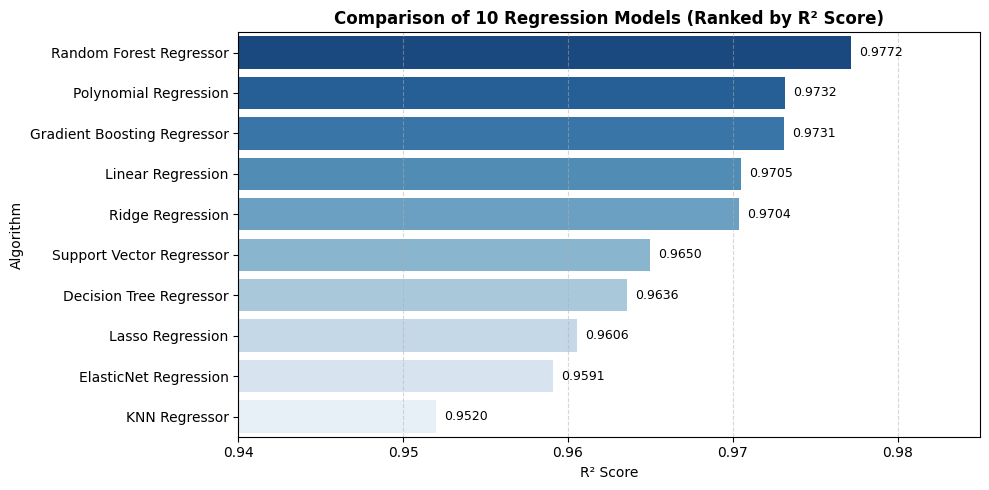

In [35]:
#Regression Comparison Bar Plot

plt.figure(figsize=(10, 5))
sns.barplot(data=regression_results, x='R2 Score', y='Algorithm', palette='Blues_r')
plt.title('Comparison of 10 Regression Models (Ranked by R² Score)', fontsize=12, fontweight='bold')
plt.xlabel('R² Score')
plt.ylabel('Algorithm')
plt.xlim(0.94, 0.985)

for index, value in enumerate(regression_results['R2 Score']):
    plt.text(value + 0.0005, index, f'{value:.4f}', va='center', fontsize=9)

plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

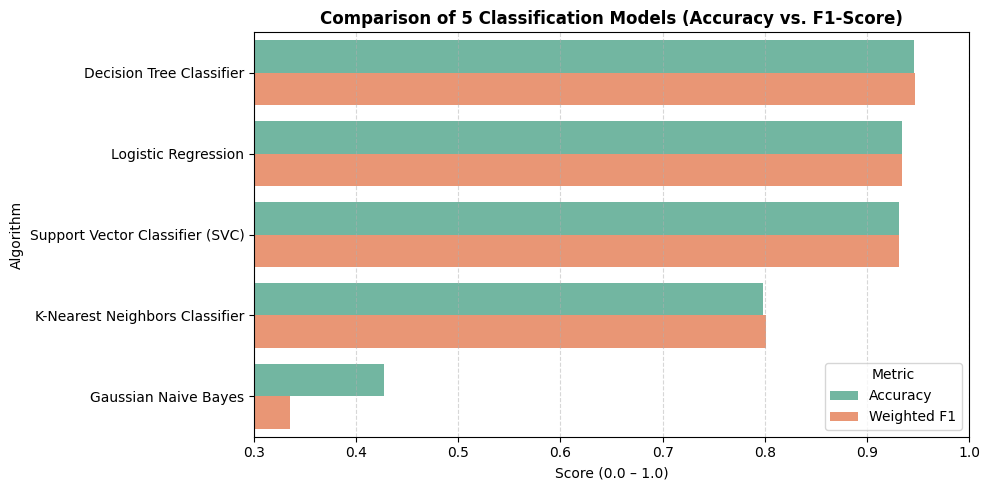

In [36]:
#Classification Model Comparison Bar Plot

import matplotlib.pyplot as plt
import seaborn as sns

# Reshape classification results for grouped bar plotting
member3_melted = member3_results.melt(
    id_vars=['Algorithm'], 
    value_vars=['Accuracy', 'Weighted F1'], 
    var_name='Metric', 
    value_name='Score'
)

plt.figure(figsize=(10, 5))
sns.barplot(data=member3_melted, x='Score', y='Algorithm', hue='Metric', palette='Set2')
plt.title('Comparison of 5 Classification Models (Accuracy vs. F1-Score)', fontsize=12, fontweight='bold')
plt.xlabel('Score (0.0 – 1.0)')
plt.ylabel('Algorithm')
plt.xlim(0.3, 1.0)
plt.legend(title='Metric', loc='lower right')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

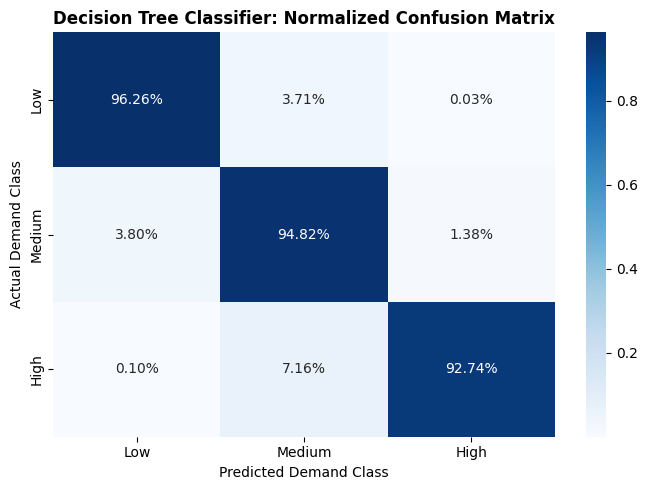

In [37]:
#Confusion Matrix Heatmap (Top Classifier: Decision Tree)

from sklearn.metrics import confusion_matrix

# Compute confusion matrix for Decision Tree Classifier
cm = confusion_matrix(y_test_cls, y_pred_dt, labels=['Low', 'Medium', 'High'])
cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]  # Normalized percentages

plt.figure(figsize=(7, 5))
sns.heatmap(
    cm_percent, 
    annot=True, 
    fmt='.2%', 
    cmap='Blues', 
    xticklabels=['Low', 'Medium', 'High'], 
    yticklabels=['Low', 'Medium', 'High']
)
plt.title('Decision Tree Classifier: Normalized Confusion Matrix', fontsize=12, fontweight='bold')
plt.xlabel('Predicted Demand Class')
plt.ylabel('Actual Demand Class')
plt.tight_layout()
plt.show()